<a href="https://colab.research.google.com/github/huangste/macro-regime-classifier/blob/main/Regime_Model_v2_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance
!pip install pandas-datareader

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_datareader.data as web
import datetime

#download asstes ex rates from yfinance and download rates from Fred

equity = ["^GSPC", "^N225", "^NDX"]
fx = ["DX-Y.NYB", "JPY=X"]
commodities = ["GC=F", "CL=F"]
credit = ["HYG"]

def get_data(tickers):
    data=yf.download(tickers, start='1990-01-01', auto_adjust=True,  progress=False, threads=False)
    close = data["Close"]

    if isinstance(close, pd.Series):
        close = close.to_frame()
    return close

eq = get_data(equity)
fx = get_data(fx)
cmd = get_data(commodities)
cred = get_data(credit)



start = datetime.datetime(1990, 1, 1)
end = datetime.datetime.today()

rates = web.DataReader(['DGS10', 'DGS2'], 'fred', start, end)
rates.head(5)



,DGS10,DGS2
DATE,,
1990-01-01,NaN,NaN
1990-01-02,7.94,7.87
1990-01-03,7.99,7.94
1990-01-04,7.98,7.92
1990-01-05,7.99,7.90


In [ ]:
# Rename columns clearly
eq.columns = ["SPX", "Nikkei", "NDX"]
fx.columns = ["DXY", "USDJPY"]
cmd.columns = ["Gold", "Oil"]
cred.columns = ["HYG"]

# Create yield curve slope
rates["US_10Y_2Y_Slope"] = rates["DGS10"] - rates["DGS2"]

# Combine all assets
raw_data = pd.concat(
    [
        eq,
        fx,
        cmd,
        rates[["DGS10", "DGS2", "US_10Y_2Y_Slope"]]
    ],
    axis=1
).sort_index()

# Forward-fill rates because FRED has holidays / missing days
raw_data = raw_data.ffill()
raw_data.isna().sum()
# Drop remaining rows with missing data
raw_data = raw_data.dropna()
raw_data.describe().round(2)


,SPX,Nikkei,NDX,DXY,USDJPY,Gold,Oil,DGS10,DGS2,US_10Y_2Y_Slope
count,6733.00,6733.00,6733.00,6733.00,6733.00,6733.00,6733.00,6733.00,6733.00,6733.00
mean,2377.11,18966.85,6351.50,92.61,113.33,64.94,1312.05,3.27,2.18,1.09
std,1586.18,10438.34,6538.76,11.11,19.10,24.61,858.80,1.22,1.65,0.95
min,676.53,7054.98,804.64,71.33,75.74,-37.63,255.10,0.52,0.09,-1.08
25%,1208.67,10889.62,1724.59,82.64,103.82,46.60,652.90,2.23,0.65,0.26
50%,1656.78,16127.42,3208.55,93.24,110.99,63.94,1253.80,3.41,1.79,1.07
75%,3006.79,22843.12,8371.93,99.57,120.50,82.52,1711.90,4.27,3.73,1.89
max,7609.78,71053.49,30660.60,120.90,161.62,145.29,5318.40,5.91,6.24,2.91


In [ ]:
# % returns for price series
returns = raw_data.pct_change()

# for rates, better to use change (not %)
rates_cols = ["DGS10", "DGS2", "US_10Y_2Y_Slope"]
returns[rates_cols] = raw_data[rates_cols].diff()

# clean
returns = returns.dropna()


features = pd.DataFrame(index=raw_data.index)

price_cols = ["SPX", "Nikkei", "NDX", "DXY", "USDJPY", "Gold", "Oil"]
rate_cols = ["DGS10", "DGS2", "US_10Y_2Y_Slope"]

# price assets: returns over different horizons
for col in price_cols:
    features[f"{col}_1d_ret"] = raw_data[col].pct_change(1)
    features[f"{col}_10d_ret"] = raw_data[col].pct_change(10)
    features[f"{col}_21d_ret"] = raw_data[col].pct_change(21)
    features[f"{col}_63d_ret"] = raw_data[col].pct_change(63)

# rates: changes, not pct returns
for col in rate_cols:
    features[f"{col}_1d_chg"] = raw_data[col].diff(1)
    features[f"{col}_10d_chg"] = raw_data[col].diff(10)
    features[f"{col}_21d_chg"] = raw_data[col].diff(21)
    features[f"{col}_63d_chg"] = raw_data[col].diff(63)

# volatility features using 1d returns
daily_ret = raw_data[price_cols].pct_change(1)

for col in price_cols:
    features[f"{col}_21d_vol"] = daily_ret[col].rolling(21).std()
    features[f"{col}_63d_vol"] = daily_ret[col].rolling(63).std()

features = features.dropna()
print(features.columns)
print(features.shape)
display(features.head().style.format("{:.3%}"))




Index(['SPX_1d_ret', 'SPX_10d_ret', 'SPX_21d_ret', 'SPX_63d_ret',
       'Nikkei_1d_ret', 'Nikkei_10d_ret', 'Nikkei_21d_ret', 'Nikkei_63d_ret',
       'NDX_1d_ret', 'NDX_10d_ret', 'NDX_21d_ret', 'NDX_63d_ret', 'DXY_1d_ret',
       'DXY_10d_ret', 'DXY_21d_ret', 'DXY_63d_ret', 'USDJPY_1d_ret',
       'USDJPY_10d_ret', 'USDJPY_21d_ret', 'USDJPY_63d_ret', 'Gold_1d_ret',
       'Gold_10d_ret', 'Gold_21d_ret', 'Gold_63d_ret', 'Oil_1d_ret',
       'Oil_10d_ret', 'Oil_21d_ret', 'Oil_63d_ret', 'DGS10_1d_chg',
       'DGS10_10d_chg', 'DGS10_21d_chg', 'DGS10_63d_chg', 'DGS2_1d_chg',
       'DGS2_10d_chg', 'DGS2_21d_chg', 'DGS2_63d_chg',
       'US_10Y_2Y_Slope_1d_chg', 'US_10Y_2Y_Slope_10d_chg',
       'US_10Y_2Y_Slope_21d_chg', 'US_10Y_2Y_Slope_63d_chg', 'SPX_21d_vol',
       'SPX_63d_vol', 'Nikkei_21d_vol', 'Nikkei_63d_vol', 'NDX_21d_vol',
       'NDX_63d_vol', 'DXY_21d_vol', 'DXY_63d_vol', 'USDJPY_21d_vol',
       'USDJPY_63d_vol', 'Gold_21d_vol', 'Gold_63d_vol', 'Oil_21d_vol',
       'Oil_63d

,SPX_1d_ret,SPX_10d_ret,SPX_21d_ret,SPX_63d_ret,Nikkei_1d_ret,Nikkei_10d_ret,Nikkei_21d_ret,Nikkei_63d_ret,NDX_1d_ret,NDX_10d_ret,NDX_21d_ret,NDX_63d_ret,DXY_1d_ret,DXY_10d_ret,DXY_21d_ret,DXY_63d_ret,USDJPY_1d_ret,USDJPY_10d_ret,USDJPY_21d_ret,USDJPY_63d_ret,Gold_1d_ret,Gold_10d_ret,Gold_21d_ret,Gold_63d_ret,Oil_1d_ret,Oil_10d_ret,Oil_21d_ret,Oil_63d_ret,DGS10_1d_chg,DGS10_10d_chg,DGS10_21d_chg,DGS10_63d_chg,DGS2_1d_chg,DGS2_10d_chg,DGS2_21d_chg,DGS2_63d_chg,US_10Y_2Y_Slope_1d_chg,US_10Y_2Y_Slope_10d_chg,US_10Y_2Y_Slope_21d_chg,US_10Y_2Y_Slope_63d_chg,SPX_21d_vol,SPX_63d_vol,Nikkei_21d_vol,Nikkei_63d_vol,NDX_21d_vol,NDX_63d_vol,DXY_21d_vol,DXY_63d_vol,USDJPY_21d_vol,USDJPY_63d_vol,Gold_21d_vol,Gold_63d_vol,Oil_21d_vol,Oil_63d_vol
2000-11-27 00:00:00,0.537%,-0.169%,-2.219%,-10.224%,2.829%,0.380%,0.948%,-12.906%,-2.147%,-2.373%,-12.784%,-30.222%,-1.165%,1.210%,-0.247%,4.423%,-0.593%,2.818%,1.880%,3.714%,-0.056%,2.759%,8.196%,5.928%,1.427%,2.194%,2.156%,-1.387%,1.000%,-13.000%,-8.000%,-17.000%,0.000%,-4.000%,-8.000%,-38.000%,1.000%,-9.000%,0.000%,21.000%,1.306%,1.261%,1.438%,1.320%,3.832%,3.417%,0.517%,0.581%,0.471%,0.445%,1.114%,2.796%,0.371%,0.635%
2000-11-28 00:00:00,-0.955%,-3.388%,-4.474%,-11.965%,-0.418%,-0.008%,1.343%,-13.062%,-5.352%,-13.765%,-14.929%,-35.719%,-0.444%,0.310%,-0.571%,3.535%,-0.362%,1.858%,1.110%,3.281%,-3.194%,-1.722%,4.389%,3.474%,-0.111%,1.850%,2.081%,-3.054%,-5.000%,-17.000%,-15.000%,-14.000%,-7.000%,-13.000%,-18.000%,-39.000%,2.000%,-4.000%,3.000%,25.000%,1.273%,1.256%,1.429%,1.320%,3.940%,3.444%,0.525%,0.583%,0.475%,0.448%,1.360%,2.824%,0.372%,0.600%
2000-11-29 00:00:00,0.437%,-3.445%,-6.119%,-11.760%,-1.032%,-1.970%,-0.220%,-13.334%,-0.697%,-15.401%,-20.700%,-36.505%,0.026%,0.223%,-0.034%,4.658%,1.044%,2.354%,2.326%,5.068%,1.109%,-2.725%,5.935%,3.745%,-1.260%,0.490%,0.566%,-3.827%,-4.000%,-17.000%,-22.000%,-13.000%,-10.000%,-21.000%,-25.000%,-40.000%,6.000%,4.000%,3.000%,27.000%,1.159%,1.257%,1.445%,1.323%,3.576%,3.441%,0.513%,0.565%,0.519%,0.455%,1.367%,2.826%,0.474%,0.617%
2000-11-30 00:00:00,-2.011%,-4.181%,-7.477%,-13.534%,0.971%,0.421%,-1.505%,-12.222%,-3.700%,-14.311%,-22.284%,-38.854%,-1.175%,-1.445%,-0.277%,3.428%,-0.853%,1.406%,1.958%,3.917%,-2.397%,-3.566%,1.807%,1.258%,1.389%,1.618%,2.349%,-2.491%,-7.000%,-20.000%,-26.000%,-20.000%,-8.000%,-26.000%,-27.000%,-48.000%,1.000%,6.000%,1.000%,28.000%,1.217%,1.278%,1.367%,1.331%,3.621%,3.461%,0.537%,0.587%,0.545%,0.470%,1.452%,2.843%,0.549%,0.644%
2000-12-01 00:00:00,0.021%,-3.838%,-7.918%,-12.730%,1.275%,2.001%,-0.017%,-9.828%,1.723%,-13.121%,-22.933%,-36.049%,-0.443%,-2.199%,-0.761%,2.064%,0.743%,2.215%,2.811%,5.035%,-5.178%,-9.972%,-1.506%,-5.178%,-0.518%,1.129%,1.626%,-2.574%,4.000%,-19.000%,-22.000%,-17.000%,1.000%,-26.000%,-25.000%,-47.000%,3.000%,7.000%,3.000%,30.000%,1.205%,1.275%,1.397%,1.334%,3.582%,3.465%,0.545%,0.580%,0.561%,0.475%,1.805%,2.914%,0.566%,0.645%


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

print(explained_var.round(3))
print(cum_var.round(3))
print(X_pca.shape)

[0.186 0.099 0.086 0.056 0.046 0.045 0.035 0.033 0.03  0.028 0.027 0.025
 0.022 0.021 0.02  0.018 0.017 0.016 0.016 0.015 0.014]
[0.186 0.286 0.372 0.428 0.474 0.519 0.554 0.587 0.617 0.646 0.673 0.697
 0.72  0.74  0.76  0.778 0.795 0.811 0.827 0.842 0.855]
(6670, 21)


In [ ]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

display(loadings.style.format("{:.3%}"))

,SPX_1d_ret,SPX_10d_ret,SPX_21d_ret,SPX_63d_ret,Nikkei_1d_ret,Nikkei_10d_ret,Nikkei_21d_ret,Nikkei_63d_ret,NDX_1d_ret,NDX_10d_ret,NDX_21d_ret,NDX_63d_ret,DXY_1d_ret,DXY_10d_ret,DXY_21d_ret,DXY_63d_ret,USDJPY_1d_ret,USDJPY_10d_ret,USDJPY_21d_ret,USDJPY_63d_ret,Gold_1d_ret,Gold_10d_ret,Gold_21d_ret,Gold_63d_ret,Oil_1d_ret,Oil_10d_ret,Oil_21d_ret,Oil_63d_ret,DGS10_1d_chg,DGS10_10d_chg,DGS10_21d_chg,DGS10_63d_chg,DGS2_1d_chg,DGS2_10d_chg,DGS2_21d_chg,DGS2_63d_chg,US_10Y_2Y_Slope_1d_chg,US_10Y_2Y_Slope_10d_chg,US_10Y_2Y_Slope_21d_chg,US_10Y_2Y_Slope_63d_chg,SPX_21d_vol,SPX_63d_vol,Nikkei_21d_vol,Nikkei_63d_vol,NDX_21d_vol,NDX_63d_vol,DXY_21d_vol,DXY_63d_vol,USDJPY_21d_vol,USDJPY_63d_vol,Gold_21d_vol,Gold_63d_vol,Oil_21d_vol,Oil_63d_vol
PC1,-3.179%,-11.356%,-16.188%,-23.655%,-3.681%,-11.935%,-16.559%,-22.182%,-2.924%,-10.488%,-14.706%,-20.847%,-0.573%,-1.264%,-0.859%,1.643%,-2.906%,-9.477%,-11.891%,-13.030%,-2.868%,-7.176%,-9.508%,-12.586%,1.150%,2.996%,4.144%,3.828%,-4.094%,-11.682%,-14.409%,-15.653%,-4.791%,-13.927%,-17.244%,-18.388%,0.642%,2.015%,2.899%,6.138%,25.883%,23.787%,21.587%,21.287%,23.363%,21.854%,19.110%,17.743%,18.165%,18.069%,8.964%,5.914%,15.348%,14.415%
PC2,7.380%,11.124%,7.817%,-4.159%,7.491%,15.140%,13.001%,5.005%,7.236%,11.902%,9.045%,-1.592%,7.747%,17.860%,18.978%,18.221%,10.033%,22.275%,21.048%,14.563%,0.345%,3.124%,1.719%,-2.505%,-7.290%,-17.179%,-18.527%,-14.334%,12.395%,25.281%,24.066%,13.132%,11.891%,24.166%,21.706%,9.664%,1.718%,3.858%,5.123%,3.624%,13.211%,17.107%,13.224%,16.251%,10.313%,12.501%,15.425%,17.103%,12.911%,16.345%,9.040%,9.122%,14.814%,18.368%
PC3,13.065%,29.634%,28.922%,13.254%,9.173%,19.160%,17.582%,4.238%,12.715%,28.968%,28.072%,14.238%,-9.881%,-24.574%,-26.316%,-20.840%,-3.130%,-10.609%,-14.219%,-17.281%,2.993%,12.243%,12.047%,5.441%,6.921%,17.781%,18.300%,17.045%,2.499%,-0.013%,-3.639%,-8.921%,1.863%,-1.106%,-4.910%,-11.576%,1.095%,1.502%,1.512%,5.167%,2.806%,12.761%,5.761%,14.278%,-0.302%,6.104%,4.513%,9.784%,7.324%,8.460%,8.924%,13.372%,5.390%,11.238%
PC4,0.867%,-7.716%,-10.605%,3.452%,-0.024%,-6.723%,-7.816%,3.227%,-0.376%,-10.088%,-13.080%,-2.628%,-4.881%,-6.888%,-8.510%,-13.741%,0.954%,2.357%,1.996%,1.292%,11.127%,16.059%,18.402%,17.569%,1.998%,1.958%,1.656%,5.155%,12.664%,21.774%,22.651%,14.937%,-3.621%,-8.616%,-9.674%,-9.892%,23.867%,43.805%,47.102%,35.911%,0.103%,-2.588%,5.649%,0.152%,8.352%,6.626%,-5.062%,-6.235%,-7.390%,-6.487%,-6.311%,-1.682%,-1.731%,-1.647%
PC5,-8.255%,-17.187%,-13.235%,-1.118%,-7.135%,-14.812%,-10.603%,0.712%,-9.297%,-17.822%,-13.402%,-1.279%,-2.106%,-10.468%,-12.017%,-9.059%,-4.922%,-12.359%,-11.272%,-11.836%,17.399%,23.136%,26.113%,22.983%,4.693%,14.754%,15.830%,13.170%,9.117%,8.238%,13.236%,18.725%,14.068%,20.165%,26.024%,29.785%,-6.198%,-15.648%,-16.965%,-19.196%,-1.170%,1.070%,1.054%,5.162%,-6.388%,-5.056%,15.836%,17.494%,11.074%,15.074%,-9.709%,-2.815%,5.609%,8.532%
PC6,42.598%,4.204%,-4.702%,-3.959%,4.303%,-15.019%,-19.515%,-15.806%,41.660%,5.609%,-3.231%,-4.164%,13.956%,3.935%,0.397%,-4.555%,15.627%,-6.296%,-11.194%,-11.707%,7.606%,-3.930%,-6.990%,-5.516%,-14.219%,-3.770%,0.460%,3.461%,42.722%,4.776%,-4.944%,-8.784%,41.115%,7.337%,-2.530%,-3.463%,5.742%,-3.084%,-3.761%,-6.991%,1.927%,-4.825%,0.617%,-5.432%,3.096%,-2.106%,-4.828%,-7.291%,-3.891%,-7.199%,-4.953%,-9.404%,-6.319%,-10.813%
PC7,10.800%,6.040%,-2.692%,-19.839%,7.676%,6.692%,1.391%,-15.121%,7.729%,1.056%,-7.322%,-23.827%,-20.073%,-5.403%,1.522%,5.177%,8.484%,19.752%,22.885%,16.281%,22.686%,29.373%,22.920%,2.498%,20.044%,11.592%,5.872%,2.982%,-9.062%,-4.064%,-3.993%,-8.822%,-6.204%,3.637%,4.084%,-1.476%,-4.746%,-10.967%,-11.646%,-10.069%,6.444%,10.387%,-7.542%,-6.867%,21.257%,25.282%,-6.962%,-4.375%,-18.410%,-16.787%,13.359%,16.392%,-24.000%,-23.026%
PC8,-29.052%,-9.501%,2.888%,-0.015%,-10.186%,-1.086%,2.589%,-6.853%,-27.005%,-6.707%,4.610%,3.205%,31.413%,12.367%,0.477%,-16.441%,5.612%,4.939%,-2.866%,-18.726%,-16.400%,4.621%,6.450%,-2.961%,-23.867%,-6.441%,5.343%,22.302%,11.605%,13.969%,6.56

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=5,
    covariance_type="diag",
    reg_covar=1e-4,
    n_init=50,
    random_state=42
)

labels = gmm.fit_predict(X_pca)
features["regime"] = labels
display(features.groupby("regime").mean().style.format("{:.3%}"))
display(features.groupby("regime").std().style.format("{:.3%}"))

,SPX_1d_ret,SPX_10d_ret,SPX_21d_ret,SPX_63d_ret,Nikkei_1d_ret,Nikkei_10d_ret,Nikkei_21d_ret,Nikkei_63d_ret,NDX_1d_ret,NDX_10d_ret,NDX_21d_ret,NDX_63d_ret,DXY_1d_ret,DXY_10d_ret,DXY_21d_ret,DXY_63d_ret,USDJPY_1d_ret,USDJPY_10d_ret,USDJPY_21d_ret,USDJPY_63d_ret,Gold_1d_ret,Gold_10d_ret,Gold_21d_ret,Gold_63d_ret,Oil_1d_ret,Oil_10d_ret,Oil_21d_ret,Oil_63d_ret,DGS10_1d_chg,DGS10_10d_chg,DGS10_21d_chg,DGS10_63d_chg,DGS2_1d_chg,DGS2_10d_chg,DGS2_21d_chg,DGS2_63d_chg,US_10Y_2Y_Slope_1d_chg,US_10Y_2Y_Slope_10d_chg,US_10Y_2Y_Slope_21d_chg,US_10Y_2Y_Slope_63d_chg,SPX_21d_vol,SPX_63d_vol,Nikkei_21d_vol,Nikkei_63d_vol,NDX_21d_vol,NDX_63d_vol,DXY_21d_vol,DXY_63d_vol,USDJPY_21d_vol,USDJPY_63d_vol,Gold_21d_vol,Gold_63d_vol,Oil_21d_vol,Oil_63d_vol
regime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.009%,-0.015%,0.142%,1.779%,-0.081%,-0.865%,-1.295%,-1.525%,-0.006%,-0.095%,0.037%,2.561%,-0.049%,-0.484%,-0.771%,-1.504%,-0.068%,-0.791%,-1.247%,-2.003%,0.029%,0.383%,0.664%,2.509%,0.126%,1.288%,2.223%,5.007%,-0.694%,-6.379%,-10.792%,-12.501%,-0.531%,-4.677%,-7.341%,-5.640%,-0.163%,-1.701%,-3.451%,-6.861%,0.976%,1.001%,1.265%,1.329%,1.326%,1.354%,0.461%,0.468%,0.578%,0.590%,2.140%,2.158%,0.961%,0.985%
1,0.088%,0.867%,1.942%,5.238%,0.199%,2.078%,4.254%,10.126%,0.141%,1.186%,2.684%,7.305%,0.039%,0.448%,0.761%,1.361%,0.084%,1.105%,1.934%,3.620%,0.072%,0.794%,1.567%,4.999%,0.000%,-0.232%,-0.145%,0.790%,0.764%,8.889%,16.097%,23.944%,0.659%,7.061%,12.282%,18.336%,0.105%,1.828%,3.815%,5.608%,0.727%,0.805%,1.137%,1.193%,1.012%,1.078%,0.436%,0.447%,0.572%,0.591%,1.967%,2.082%,0.998%,1.020%
2,0.080%,1.004%,1.950%,4.847%,0.117%,1.026%,1.813%,3.810%,0.104%,1.349%,2.674%,6.614%,0.005%,0.028%,0.006%,0.065%,0.036%,0.276%,0.494%,1.020%,0.109%,0.778%,1.517%,4.218%,0.029%,0.288%,0.598%,1.790%,0.011%,0.047%,0.061%,0.131%,0.182%,1.560%,2.720%,6.137%,-0.170%,-1.513%,-2.659%,-6.005%,0.604%,0.677%,0.896%,0.977%,0.822%,0.918%,0.325%,0.345%,0.414%,0.453%,1.666%,1.779%,0.779%,0.844%
3,-0.095%,-1.608%,-3.638%,-10.348%,-0.144%,-1.607%,-3.582%,-11.487%,0.102%,-0.719%,-2.545%,-8.029%,0.011%,0.317%,0.438%,3.364%,-0.077%,-0.676%,-1.779%,-4.519%,-1.746%,-3.042%,-5.274%,-23.190%,0.143%,0.943%,1.831%,2.594%,-1.352%,-7.146%,-17.390%,-58.479%,-1.718%,-10.310%,-23.549%,-79.113%,0.366%,3.164%,6.160%,20.634%,2.981%,3.108%,2.772%,2.857%,3.073%,3.193%,0.750%,0.733%,1.551%,1.583%,12.155%,16.019%,1.851%,1.934%
4,-0.034%,-0.397%,-1.027%,-3.686%,-0.062%,-0.565%,-1.441%,-3.250%,-0.057%,-0.507%,-1.343%,-5.725%,0.011%,0.028%,0.017%,-0.375%,0.009%,0.000%,0.019%,0.575%,-0.035%,-0.040%,0.595%,4.032%,-0.004%,0.263%,0.905%,4.150%,0.224%,-1.007%,-2.537%,-7.171%,-0.072%,-3.039%,-6.133%,-17.636%,0.296%,2.032%,3.596%,10.466%,1.500%,1.435%,1.703%,1.619%,2.173%,2.127%,0.547%,0.533%,0.712%,0.717%,2.670%,2.639%,1.260%,1.210%


,SPX_1d_ret,SPX_10d_ret,SPX_21d_ret,SPX_63d_ret,Nikkei_1d_ret,Nikkei_10d_ret,Nikkei_21d_ret,Nikkei_63d_ret,NDX_1d_ret,NDX_10d_ret,NDX_21d_ret,NDX_63d_ret,DXY_1d_ret,DXY_10d_ret,DXY_21d_ret,DXY_63d_ret,USDJPY_1d_ret,USDJPY_10d_ret,USDJPY_21d_ret,USDJPY_63d_ret,Gold_1d_ret,Gold_10d_ret,Gold_21d_ret,Gold_63d_ret,Oil_1d_ret,Oil_10d_ret,Oil_21d_ret,Oil_63d_ret,DGS10_1d_chg,DGS10_10d_chg,DGS10_21d_chg,DGS10_63d_chg,DGS2_1d_chg,DGS2_10d_chg,DGS2_21d_chg,DGS2_63d_chg,US_10Y_2Y_Slope_1d_chg,US_10Y_2Y_Slope_10d_chg,US_10Y_2Y_Slope_21d_chg,US_10Y_2Y_Slope_63d_chg,SPX_21d_vol,SPX_63d_vol,Nikkei_21d_vol,Nikkei_63d_vol,NDX_21d_vol,NDX_63d_vol,DXY_21d_vol,DXY_63d_vol,USDJPY_21d_vol,USDJPY_63d_vol,Gold_21d_vol,Gold_63d_vol,Oil_21d_vol,Oil_63d_vol
regime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.978%,2.838%,3.797%,6.147%,1.255%,3.489%,4.542%,7.470%,1.346%,3.849%,5.280%,8.778%,0.441%,1.331%,1.991%,3.703%,0.542%,1.465%,1.979%,3.855%,2.277%,7.002%,9.517%,17.168%,0.912%,2.810%,3.969%,6.767%,4.920%,13.386%,18.347%,33.807%,4.423%,12.157%,17.977%,34.034%,3.165%,9.062%,12.618%,24.983%,0.326%,0.322%,0.423%,0.360%,0.498%,0.502%,0.115%,0.104%,0.184%,0.165%,0.704%,0.603%,0.282%,0.258%
1,0.715%,2.048%,2.925%,4.613%,1.116%,3.337%,4.686%,7.923%,1.011%,2.889%,4.098%,7.499%,0.442%,1.336%,1.810%,3.289%,0.565%,1.671%,2.432%,4.526%,2.003%,5.713%,8.614%,16.669%,1.054%,3.192%,4.501%,7.996%,5.218%,14.590%,21.109%,38.119%,4.308%,12.213%,18.126%,35.035%,3.638%,10.796%,15.691%,30.380%,0.224%,0.228%,0.388%,0.361%,0.389%,0.382%,0.113%,0.102%,0.210%,0.183%,0.777%,0.745%,0.329%,0.282%
2,0.513%,1.479%,2.090%,3.465%,0.798%,2.436%,3.304%,5.817%,0.716%,2.223%,3.083%,4.963%,0.289%,0.972%,1.458%,2.571%,0.372%,1.100%,1.558%,2.604%,1.561%,4.803%,7.250%,11.394%,0.663%,2.271%,3.385%,5.456%,3.384%,10.403%,14.117%,24.485%,2.639%,7.929%,11.419%,21.768%,2.295%,6.863%,9.714%,18.335%,0.202%,0.211%,0.251%,0.259%,0.266%,0.268%,0.082%,0.080%,0.129%,0.126%,0.572%,0.491%,0.216%,0.231%
3,3.601%,8.048%,11.204%,17.541%,3.536%,9.041%,12.647%,19.878%,3.950%,8.427%,12.130%,21.802%,0.894%,2.892%,4.034%,6.323%,2.219%,3.182%,3.648%,6.154%,23.847%,31.888%,45.946%,51.149%,2.439%,5.999%,7.849%,10.416%,10.978%,29.460%,44.546%,59.723%,11.126%,21.178%,32.072%,52.309%,8.328%,25.366%,35.947%,44.829%,1.491%,1.041%,1.539%,1.179%,1.518%,0.976%,0.285%,0.226%,1.511%,1.123%,20.349%,17.477%,0.751%,0.568%
4,1.625%,4.562%,6.382%,8.089%,1.890%,5.360%,7.255%,10.795%,2.383%,6.765%,9.600%,13.483%,0.617%,1.821%,2.665%,4.533%,0.844%,2.338%,3.449%,5.880%,3.051%,8.777%,12.524%,26.516%,1.444%,4.376%,6.097%,9.293%,7.702%,22.732%,33.008%,58.754%,8.008%,24.955%,36.104%,74.142%,5.054%,15.640%,23.530%,43.420%,0.625%,0.528%,0.615%,0.422%,1.040%,0.995%,0.153%,0.135%,0.261%,0.340%,1.300%,1.163%,0.580%,0.456%


In [ ]:
summary_cols = [
    "SPX_21d_ret", "SPX_63d_ret",
    "NDX_21d_ret", "NDX_63d_ret",
    "DXY_21d_ret",
    "USDJPY_21d_ret",
    "Gold_21d_ret",
    "Oil_21d_ret",
    "DGS10_21d_chg",
    "DGS2_21d_chg",
    "US_10Y_2Y_Slope_21d_chg",
    "SPX_21d_vol",
    "NDX_21d_vol"
]

regime_summary = features.groupby("regime")[summary_cols].mean()
display(regime_summary.style.format("{:.2%}"))
display(pd.Series(labels).value_counts(normalize=True))



,SPX_21d_ret,SPX_63d_ret,NDX_21d_ret,NDX_63d_ret,DXY_21d_ret,USDJPY_21d_ret,Gold_21d_ret,Oil_21d_ret,DGS10_21d_chg,DGS2_21d_chg,US_10Y_2Y_Slope_21d_chg,SPX_21d_vol,NDX_21d_vol
regime,,,,,,,,,,,,,
0,0.14%,1.78%,0.04%,2.56%,-0.77%,-1.25%,0.66%,2.22%,-10.79%,-7.34%,-3.45%,0.98%,1.33%
1,1.94%,5.24%,2.68%,7.30%,0.76%,1.93%,1.57%,-0.15%,16.10%,12.28%,3.82%,0.73%,1.01%
2,1.95%,4.85%,2.67%,6.61%,0.01%,0.49%,1.52%,0.60%,0.06%,2.72%,-2.66%,0.60%,0.82%
3,-3.64%,-10.35%,-2.55%,-8.03%,0.44%,-1.78%,-5.27%,1.83%,-17.39%,-23.55%,6.16%,2.98%,3.07%
4,-1.03%,-3.69%,-1.34%,-5.73%,0.02%,0.02%,0.59%,0.90%,-2.54%,-6.13%,3.60%,1.50%,2.17%


,proportion
0,0.291304
2,0.239430
1,0.236132
4,0.201199
3,0.031934


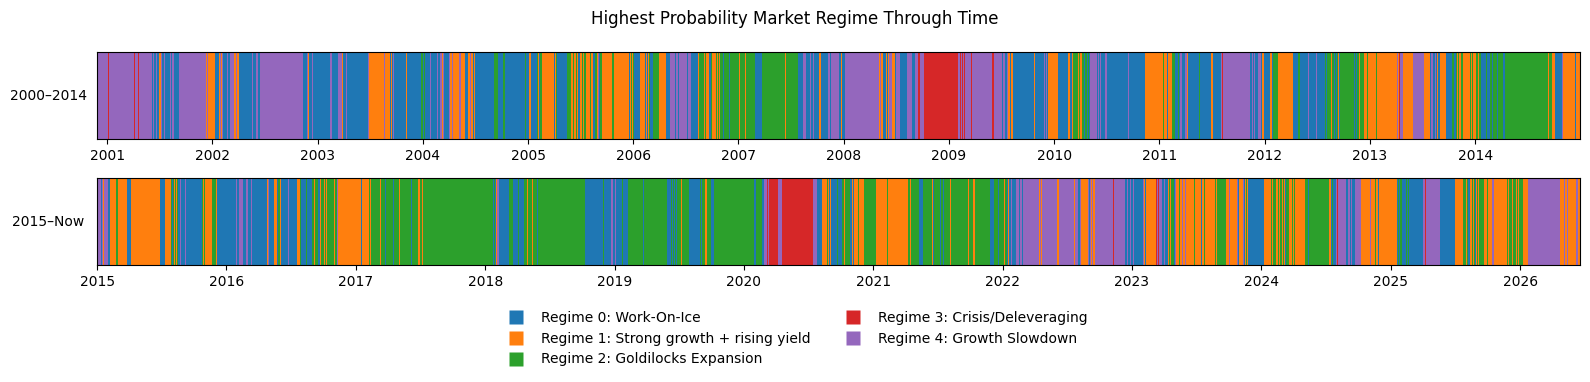

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.colors import ListedColormap

df_plot = raw_data.loc[features.index].copy()
df_plot["regime"] = labels
split_date = "2015-01-01"

df_1 = df_plot[df_plot.index < split_date]
df_2 = df_plot[df_plot.index >= split_date]


# Optional: map regime numbers to names
regime_names = {
    0: "Work-On-Ice",
    1: "Strong growth + rising yield",
    2: "Goldilocks Expansion",
    3: "Crisis/Deleveraging",
    4: "Growth Slowdown"
}

# Convert regimes into a 2D array for imshow

max_len = max(len(df_1), len(df_2))

row1 = np.pad(
    df_1["regime"].values.astype(float),
    (0, max_len - len(df_1)),
    constant_values=np.nan
)

row2 = np.pad(
    df_2["regime"].values.astype(float),
    (0, max_len - len(df_2)),
    constant_values=np.nan
)

regime_array = np.vstack([row1, row2])
# Choose 5 distinct colors
cmap = ListedColormap([
    "#1f77b4",  # regime 0
    "#ff7f0e",  # regime 1
    "#2ca02c",  # regime 2
    "#d62728",  # regime 3
    "#9467bd"   # regime 4
])

fig, axes = plt.subplots(2, 1, figsize=(16, 3), sharex=False)

periods = [
    ("2000–2014", df_1),
    ("2015–Now", df_2)
]

for ax, (title, df_period) in zip(axes, periods):
    regime_array = df_period["regime"].values.reshape(1, -1)

    ax.imshow(
        regime_array,
        aspect="auto",
        cmap=cmap,
        interpolation="nearest",
        extent=[
            mdates.date2num(df_period.index[0]),
            mdates.date2num(df_period.index[-1]),
            0,
            1
        ]
    )

    ax.set_yticks([])
    ax.set_ylabel(title, rotation=0, labelpad=35, va="center")

    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Highest Probability Market Regime Through Time")


handles = [
    plt.Line2D([0], [0], marker="s", linestyle="", markersize=10,
               markerfacecolor=cmap(i), markeredgecolor="none",
               label=f"Regime {i}: {regime_names[i]}")
    for i in sorted(regime_names)
]


fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.25)
)

plt.tight_layout()
plt.show()

In [ ]:
D=21

trans_matrix = pd.crosstab(
    labels[:-D],
    labels[D:],
    normalize='index'
)

display(trans_matrix.style.format("{:.3%}"))

col_0,0,1,2,3,4
row_0,,,,,
0,48.893%,20.072%,16.830%,0.515%,13.690%
1,23.926%,45.542%,19.628%,0.449%,10.455%
2,18.848%,16.907%,59.361%,0.626%,4.258%
3,7.512%,2.817%,0.469%,63.380%,25.822%
4,22.663%,14.884%,1.122%,3.815%,57.517%


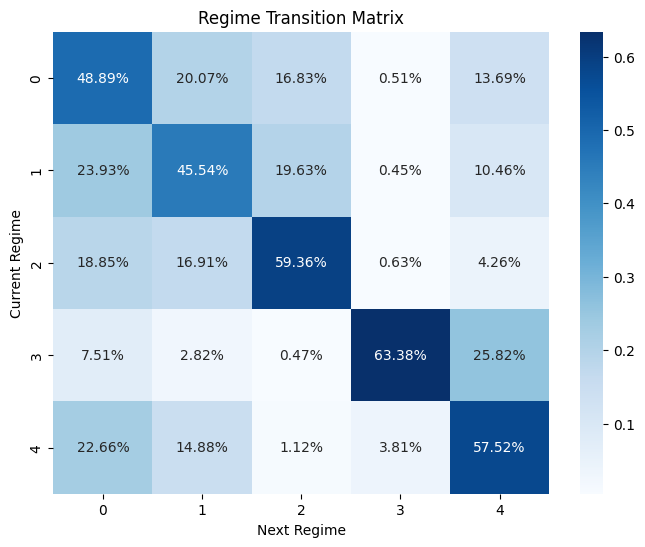

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(trans_matrix, annot=True, fmt=".2%", cmap="Blues")
plt.title("Regime Transition Matrix")
plt.xlabel("Next Regime")
plt.ylabel("Current Regime")
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss, make_scorer

tscv = TimeSeriesSplit(n_splits=2)
# allow timeseries split to 2 as some of label not in the class if we make split=3
H=21

print(labels.shape)
print(X_pca.shape)

# classify 1, 3 as crisis, and rest is risk on
stress_labels = np.where(
    np.isin(labels, [3, 4]),
    1,   # Stress / risk-off
    0    # Risk-on / normal
)

y = stress_labels[H:]
X = X_pca[:-H]


model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced"
)


fixed_log_loss = make_scorer(
    log_loss,
    response_method="predict_proba",
    greater_is_better=False,
    labels=[0, 1]
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=tscv,
    scoring=fixed_log_loss
)

display(scores)
display(scores.mean())

(6670,)
(6670, 21)


array([-0.36956841, -0.4453325 ])

np.float64(-0.4074504567660042)

In [ ]:
print(labels[-1])

1


In [ ]:
model.fit(X, y)

# Latest current state
X_current = X_pca[-1].reshape(1, -1)

# Predict regime probabilities H days ahead
current_probs = model.predict_proba(X_current)

# Put into readable table
prob_table = pd.DataFrame(
    current_probs,
    columns=[f"Regime {c}" for c in model.classes_]
).T

prob_table.columns = [f"Probability of regime in {H} trading days"]
prob_table.style.format("{:.3%}")

,Probability of regime in 21 trading days
Regime 0,73.598%
Regime 1,26.402%


In [ ]:
model.score(X, y)

0.8942539109506619

In [ ]:
regime_names = {
    0: "Riks on",
    1: "Risk off",
}

prob_table = pd.DataFrame({
    "Regime": model.classes_,
    "Label": [regime_names[c] for c in model.classes_],
    f"Probability in {H} trading days": current_probs[0]
})

prob_table.sort_values(
    f"Probability in {H} trading days",
    ascending=False
).style.format({f"Probability in {H} trading days": "{:.2%}"})

,Regime,Label,Probability in 21 trading days
0,0,Riks on,73.60%
1,1,Risk off,26.40%


In [ ]:
import numpy as np
from sklearn.metrics import log_loss



for cw in [None, "balanced"]:
    model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight=cw
    )
    scores = cross_val_score(
        model, X, y,
        cv=tscv,
        scoring=fixed_log_loss
    )
    print(cw, scores.mean())

base_rate = pd.Series(y).value_counts(normalize=True).sort_index()

# unconditional probs
base_probs = np.tile(base_rate.values, (len(y), 1))

baseline_loss = log_loss(y, base_probs)*(-1)
print("Baseline:",baseline_loss)

None -0.39132622240486337
balanced -0.4074504567660042
Baseline: -0.5401344884359457


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "logistic": LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ),

    "rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),

    "gbm": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "knn": KNeighborsClassifier(
        n_neighbors=20
    )
}

results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=tscv,
        scoring=fixed_log_loss
    )

    results[name] = scores.mean()

    print(name, scores.mean())


logistic -0.39132622240486337
rf -0.39567147626699095
gbm -0.40410597753790123
knn -1.4086596433749508


In [ ]:
gbm = models["gbm"]

gbm.fit(X, y)

gbm.predict_proba(X_current)

array([[0.8774873, 0.1225127]])

In [ ]:
print(gbm.classes_)

[0 1]


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import log_loss
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
num_classes = len(np.unique(y))
input_dim = X.shape[1]

y_cat = to_categorical(y, num_classes=num_classes)

In [ ]:
def build_mlp(input_dim, num_classes):
    model = Sequential([
        Dense(32, activation="relu", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.20),

        Dense(16, activation="relu"),
        Dropout(0.20),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tscv = TimeSeriesSplit(n_splits=4)

nn_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip fold if not all classes are present
    if len(np.unique(y_train)) < num_classes:
        print(f"Skipping fold {fold}: not all classes in training set")
        continue

    y_train_cat = to_categorical(y_train, num_classes=num_classes)

    model = build_mlp(input_dim, num_classes)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train_cat,
        validation_split=0.2,
        epochs=200,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    probs = model.predict(X_test, verbose=0)

    score = log_loss(y_test, probs, labels=[0,1])
    nn_scores.append(score)

    print(f"Fold {fold} log loss:", score)

print("NN average log loss:", np.mean(nn_scores))
print("NN negative log loss:", -np.mean(nn_scores))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 0 log loss: 0.6910826777258302


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 log loss: 0.3613965935076155


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 log loss: 0.1841761826348525


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 log loss: 0.6598650013321122
NN average log loss: 0.4741301138001026
NN negative log loss: -0.4741301138001026


In [ ]:
final_nn = build_mlp(input_dim, num_classes)

early_stop = EarlyStopping(
    monitor="loss",
    patience=20,
    restore_best_weights=True
)

final_nn.fit(
    X,
    y_cat,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

current_probs_nn = final_nn.predict(X_current, verbose=0)[0]

nn_prob_table = pd.DataFrame({
    "Regime": np.arange(num_classes),
    "Label": [regime_names[i] for i in range(num_classes)],
    f"NN Probability in {H} trading days": current_probs_nn
}).sort_values(
    f"NN Probability in {H} trading days",
    ascending=False
)

nn_prob_table.style.format({f"NN Probability in {H} trading days": "{:.2%}"})

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Regime,Label,NN Probability in 21 trading days
0,0,Riks on,97.09%
1,1,Risk off,2.91%


In [ ]:
gbm.feature_importances_

array([0.5579662 , 0.10177812, 0.02319507, 0.01960035, 0.05653068,
       0.01277927, 0.07802118, 0.00419852, 0.04090372, 0.0117144 ,
       0.0143764 , 0.01162778, 0.00156294, 0.00947093, 0.01259156,
       0.01111869, 0.01391281, 0.01152299, 0.00095392, 0.00395096,
       0.00222352])

In [ ]:
feature_cols = features.drop(columns=["regime"], errors="ignore").columns

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

for pc in ["PC1", "PC2", "PC3"]:
    print(pc)
    display(
        loadings[pc]
        .sort_values(key=np.abs, ascending=False)
        .head(10)
    )


PC1


,PC1
SPX_21d_vol,0.258835
SPX_63d_vol,0.237873
SPX_63d_ret,-0.236551
NDX_21d_vol,0.233633
Nikkei_63d_ret,-0.221815
NDX_63d_vol,0.218536
Nikkei_21d_vol,0.215869
Nikkei_63d_vol,0.212870
NDX_63d_ret,-0.208474
DXY_21d_vol,0.191098


PC2


,PC2
DGS10_10d_chg,0.252810
DGS2_10d_chg,0.241656
DGS10_21d_chg,0.240663
USDJPY_10d_ret,0.222749
DGS2_21d_chg,0.217065
USDJPY_21d_ret,0.210481
DXY_21d_ret,0.189783
Oil_21d_ret,-0.185275
Oil_63d_vol,0.183685
DXY_63d_ret,0.182208


PC3


,PC3
SPX_10d_ret,0.296340
NDX_10d_ret,0.289682
SPX_21d_ret,0.289220
NDX_21d_ret,0.280716
DXY_21d_ret,-0.263158
DXY_10d_ret,-0.245738
DXY_63d_ret,-0.208399
Nikkei_10d_ret,0.191600
Oil_21d_ret,0.183001
Oil_10d_ret,0.177808


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import pandas as pd

models = {
    "logistic": LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ),

    "rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),

    "gbm": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "knn": KNeighborsClassifier(
        n_neighbors=20
    )
}

results = []

for n in [2, 3, 4, 5]:

    tscv = TimeSeriesSplit(n_splits=n)

    for name, model in models.items():

        scores = cross_val_score(
            model,
            X,
            y,
            cv=tscv,
            scoring=fixed_log_loss
        )

        # fit full sample
        model.fit(X, y)

        probs = model.predict_proba(X_current)[0]

        results.append({
            "Model": name,
            "n_splits": n,
            "Log Loss": scores.mean(),
            "P(Risk-On)": probs[0],
            "P(Risk-Off)": probs[1]
        })

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "Log Loss": "{:.3f}",
        "P(Risk-On)": "{:.1%}",
        "P(Risk-Off)": "{:.1%}"
    })
)

,Model,n_splits,Log Loss,P(Risk-On),P(Risk-Off)
0,logistic,2,-0.391,91.7%,8.3%
1,rf,2,-0.396,82.8%,17.2%
2,gbm,2,-0.404,87.7%,12.3%
3,knn,2,-1.409,100.0%,0.0%
4,logistic,3,-0.459,91.7%,8.3%
5,rf,3,-0.434,82.8%,17.2%
6,gbm,3,-0.428,87.7%,12.3%
7,knn,3,-1.933,100.0%,0.0%
8,logistic,4,-0.457,91.7%,8.3%
9,rf,4,-0.421,82.8%,17.2%
